In [364]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
from uncertainties import ufloat, ufloat_fromstr
import seaborn as sns
import re

In [365]:
abatement_cost_gwp_star = pd.read_csv('/Users/yash/Documents/GitHub/DACCSvDACCU/outputs/GWP*_abatement_cost.csv')
abatement_cost_gwp_20 = pd.read_csv('/Users/yash/Documents/GitHub/DACCSvDACCU/outputs/GWP20_abatement_cost.csv')
abatement_cost_gwp_100 = pd.read_csv('/Users/yash/Documents/GitHub/DACCSvDACCU/outputs/GWP100_abatement_cost.csv')
abatement_cost_gwp_star.loc[:,"24"]= abatement_cost_gwp_star.loc[:,"24"].apply(lambda x: ufloat_fromstr(x))
abatement_cost_gwp_star[["Abatement Cost Low", "Abatement Cost High", "Abatement Cost Nominal", "Standard Deviation"]] = abatement_cost_gwp_star["24"].apply(
    lambda x: pd.Series({
        "Abatement Cost Low": x.nominal_value - x.std_dev,
        "Abatement Cost High": x.nominal_value + x.std_dev,
        "Abatement Cost Average": x.nominal_value,
        "Standard Deviation": x.std_dev
    })
)
abatement_cost_dfs = {"GWP20": abatement_cost_gwp_20, "GWP100": abatement_cost_gwp_100, "GWP*": abatement_cost_gwp_star}

In [366]:
for df in abatement_cost_dfs.values():
    df.rename(columns = {'Unnamed: 0':'Quartile', '24': 'Abatement Cost'}, inplace = True)

In [367]:
# GWP abatement cost dfs are those that don't have GWP* in the name
gwp_abatement_cost_dfs = {k: v for k, v in abatement_cost_dfs.items() if "GWP*" not in k}

/var/folders/02/f8g3z62n7qxgc0xv8jd6gf800000gn/T/ipykernel_70808/1015433341.py:23: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  rect = patches.Rectangle(
/var/folders/02/f8g3z62n7qxgc0xv8jd6gf800000gn/T/ipykernel_70808/1015433341.py:51: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  rect = patches.Rectangle(


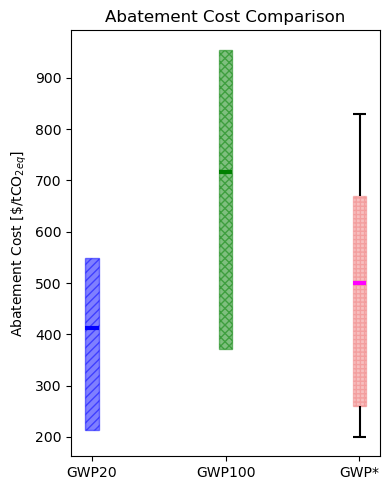

In [368]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Assuming `gwp_abatement_cost_dfs` is a dictionary with keys GWP20 and GWP100
fig, ax = plt.subplots(figsize=(4, 5))

bar_width = 0.1  # Width of each bar
colors = ['blue', 'green', 'lightcoral']  # Colors for GWP20, GWP100, and the GWP* bar
hatches = ['////', 'xxxx', '++++']  # Hatching styles (None for the GWP* bar)

# Loop through each dataset and plot bars
for i, (df_name, df) in enumerate(gwp_abatement_cost_dfs.items()):
    # Extract values
    median_cost = df.loc[df["Quartile"] == "50%", "Abatement Cost"].values[0]
    lower_cost = df.loc[df["Quartile"] == "25%", "Abatement Cost"].values[0]
    upper_cost = df.loc[df["Quartile"] == "75%", "Abatement Cost"].values[0]

    # Calculate bar height and position
    x_position = i  # Position for this bar
    bar_height = upper_cost - lower_cost

    # Add the hatched bar
    rect = patches.Rectangle(
        (x_position - bar_width / 2, lower_cost),  # Bottom-left corner
        bar_width,  # Width of the bar
        bar_height,  # Height of the bar
        color=colors[i],  # Fill color
        alpha=0.5,  # Transparency
        hatch=hatches[i],  # Hatching style
        edgecolor='black',  # Edge color
    )
    ax.add_patch(rect)

    # Add the median line
    ax.hlines(
        median_cost,  # y-coordinate of the line
        x_position - bar_width / 2,  # Start of the line
        x_position + bar_width / 2,  # End of the line
        colors=colors[i],  # Line color
        linewidth=3,  # Thickness of the line
        label=f'{df_name} Median'
    )

x_position = len(gwp_abatement_cost_dfs)  # Position for the new bar
abatement_cost_gwp_star.set_index("Quartile", inplace=True)
median_cost = abatement_cost_gwp_star.loc["50%", "Abatement Cost Nominal"]
lower_cost = abatement_cost_gwp_star.loc["25%", "Abatement Cost Nominal"]
upper_cost = abatement_cost_gwp_star.loc["75%", "Abatement Cost Nominal"]

# Add new rectangle
rect = patches.Rectangle(
    (x_position - bar_width / 2, lower_cost),  # Bottom-left corner
    bar_width,  # Width of the bar
    upper_cost - lower_cost,  # Height of the bar
    color=colors[-1],  # Fill color
    alpha=0.5,  # Transparency
    hatch=hatches[-1],  # Hatching style
    edgecolor='black',  # Edge color
)

ax.add_patch(rect)

error_bar_lower = abatement_cost_gwp_star.loc["25%", "Abatement Cost Low"]
error_bar_higher = abatement_cost_gwp_star.loc["75%", "Abatement Cost High"]

# Horizontal line at median

ax.hlines(
    median_cost,
    x_position - bar_width / 2,
    x_position + bar_width / 2,
    colors="magenta",
    linewidth=3,
    label='GWP* Median'
)

# Add whiskers from upper and lower cost to error_bar_higher and error_bar_lower
ax.vlines(
    x=x_position + 0.005,
    ymin=error_bar_lower,
    ymax=lower_cost,
    color="black",
    linestyle='-',
    label='GWP* Lower Whisker'
)

ax.vlines(
    x=x_position + 0.005,
    ymin=upper_cost,
    ymax=error_bar_higher,
    color="black",
    linestyle='-',
    label='GWP* Upper Whisker'
)

# Horizontal lines at error_bar_higher and error_bar_lower
ax.hlines(
    y=error_bar_lower,
    xmin=x_position - bar_width / 2,
    xmax=x_position + bar_width / 2,
    colors="black",
    linestyle='-',
    label='GWP* Lower Error Bar'
)

ax.hlines(
    y=error_bar_higher,
    xmin=x_position - bar_width / 2,
    xmax=x_position + bar_width / 2,
    colors="black",
    linestyle='-',
    label='GWP* Upper Error Bar'
)

# Customize plot
ax.set_xticks(list(range(len(gwp_abatement_cost_dfs) + 1)))
ax.set_xticklabels(list(gwp_abatement_cost_dfs.keys()) + ["GWP*"])
ax.set_ylabel(r"Abatement Cost [\$/tCO$_{2eq}$]")
ax.set_title("Abatement Cost Comparison")

# Adjust layout and show plot
plt.tight_layout()
plt.show()
